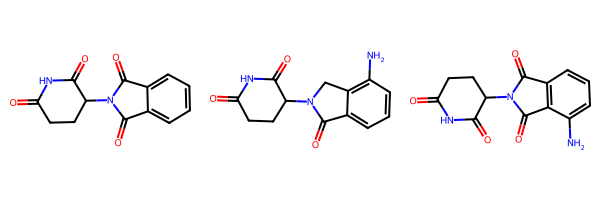

In [2]:
from rdkit import Chem
from rdkit.Chem import Draw
smiles = ['O=C1NC(=O)C(N2C(=O)C=3C=CC=CC3C2=O)CC1', 'O=C1NC(=O)C(N2C(=O)C=3C=CC=C(N)C3C2)CC1', 'O=C1CCC(C(=O)N1)N1C(=O)c2c(C1=O)c(N)ccc2']
mols = [Chem.MolFromSmiles(s) for s in smiles]
Draw.MolsToGridImage(mols, molsPerRow=3)

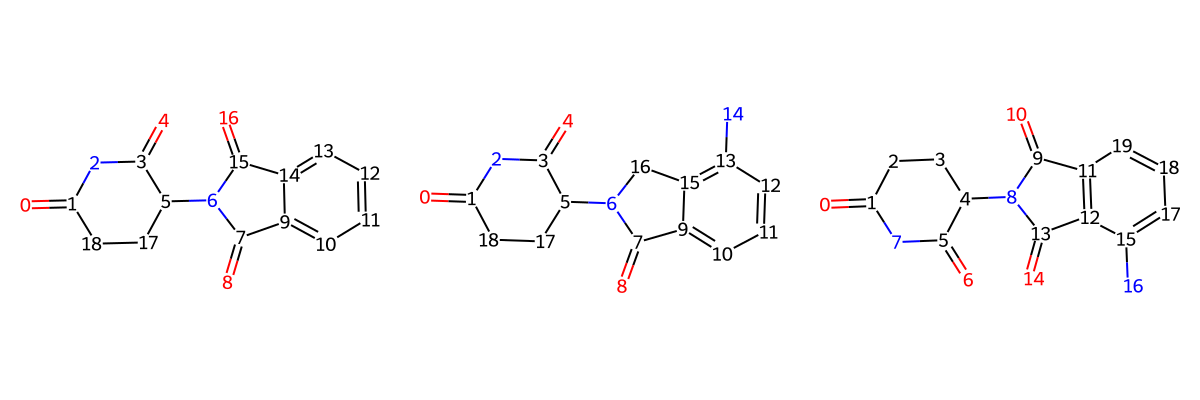

In [5]:
#Draw structure with atom indices
def draw_with_indices(mol):
    for atom in mol.GetAtoms():
        atom.SetProp('atomLabel', str(atom.GetIdx()))
    return mol

mols_with_indices = [draw_with_indices(Chem.Mol(mol)) for mol in mols]
Draw.MolsToGridImage(mols_with_indices, molsPerRow=3, subImgSize=(400, 400))

In [6]:
from rdkit.Chem.rdmolops import GetAdjacencyMatrix
import pandas as pd

for mol in mols:
    adj_matrix = GetAdjacencyMatrix(mol)
    atoms = [atom.GetSymbol() for atom in mol.GetAtoms()]
    df_adj = pd.DataFrame(adj_matrix, index=atoms, columns=atoms)
    print("\n--- Adjacency Matrix (Pandas DataFrame with Atom Symbols) ---")
    print(df_adj)



--- Adjacency Matrix (Pandas DataFrame with Atom Symbols) ---
   O  C  N  C  O  C  N  C  O  C  C  C  C  C  C  C  O  C  C
O  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
C  1  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1
N  0  1  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
C  0  0  1  0  1  1  0  0  0  0  0  0  0  0  0  0  0  0  0
O  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
C  0  0  0  1  0  0  1  0  0  0  0  0  0  0  0  0  0  1  0
N  0  0  0  0  0  1  0  1  0  0  0  0  0  0  0  1  0  0  0
C  0  0  0  0  0  0  1  0  1  1  0  0  0  0  0  0  0  0  0
O  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0
C  0  0  0  0  0  0  0  1  0  0  1  0  0  0  1  0  0  0  0
C  0  0  0  0  0  0  0  0  0  1  0  1  0  0  0  0  0  0  0
C  0  0  0  0  0  0  0  0  0  0  1  0  1  0  0  0  0  0  0
C  0  0  0  0  0  0  0  0  0  0  0  1  0  1  0  0  0  0  0
C  0  0  0  0  0  0  0  0  0  0  0  0  1  0  1  0  0  0  0
C  0  0  0  0  0  0  0  0  0  1  0  0  0  1  0  1  0

In [13]:
import deepchem.feat.molecule_featurizers.mol_graph_conv_featurizer as mgcf
canonical_smiles = [Chem.MolToSmiles(mol) for mol in mols]
featurizer = mgcf.MolGraphConvFeaturizer(use_edges=True)
out = featurizer.featurize(canonical_smiles)
out

array([GraphData(node_features=[19, 30], edge_index=[2, 42], edge_features=[42, 11]),
       GraphData(node_features=[19, 30], edge_index=[2, 42], edge_features=[42, 11]),
       GraphData(node_features=[20, 30], edge_index=[2, 44], edge_features=[44, 11])],
      dtype=object)

In [14]:
out[0]

GraphData(node_features=[19, 30], edge_index=[2, 42], edge_features=[42, 11])

In [16]:
graph_data = out[0]

print("Node features shape:", graph_data.node_features.shape)
print("Node features sample:\n", graph_data.node_features[:])

print("\nEdge index shape:", graph_data.edge_index.shape)
print("Edge index sample:\n", graph_data.edge_index[:, :])

if hasattr(graph_data, 'edge_features') and graph_data.edge_features is not None:
    print("\nEdge features shape:", graph_data.edge_features.shape)
    print("Edge features sample:\n", graph_data.edge_features[:])
else:
    print("\nNo edge features found.")

Node features shape: (19, 30)
Node features sample:
 [[0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0.
  1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.
  0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.
  1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.
  0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0.
  1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0.
  0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.
  1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
  0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0.
  1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
  1. 0. 0. 0. 0. 0

In [17]:
# Inspect the featurizer to understand feature dimensions
print(f"Node features shape: {graph_data.node_features.shape}")
print(f"Edge features shape: {graph_data.edge_features.shape if graph_data.edge_features is not None else 'None'}")

# Usually, MolGraphConvFeaturizer uses the following default features:
# Node (Atom) Features (length ~30):
# - Atom type (one-hot: C, N, O, F, P, S, Cl, Br, I, etc.)
# - Degree (number of bonds)
# - Formal charge
# - Hybridization
# - Aromaticity
# - Total Num H

# Edge (Bond) Features (length ~11):
# - Bond type (Single, Double, Triple, Aromatic)
# - Conjugated?
# - In ring?
# - Stereo

print("\nFirst atom features:", graph_data.node_features[0])
print("First edge features:", graph_data.edge_features[0] if graph_data.edge_features is not None else "No edge features")

Node features shape: (19, 30)
Edge features shape: (42, 11)

First atom features: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 0.]
First edge features: [0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0.]


### Understanding the Graph Data Components

The `GraphData` object returned by `MolGraphConvFeaturizer` contains the following main components, which serve as the input for Graph Neural Networks (GNNs):

1.  **`node_features` (Atom Features)**:
    -   **Shape**: `(num_atoms, num_node_features)`
    -   **Meaning**: Each row represents an atom in the molecule. The columns are a vector of properties (features) for that atom.
    -   **Typical Features**: By default, DeepChem uses a one-hot encoding for:
        -   **Atom Type** (C, N, O, F, P, S, Cl, Br, I, etc.)
        -   **Degree** (Number of bonds)
        -   **Implicit Valence**
        -   **Formal Charge**
        -   **Number of Radical Electrons**
        -   **Hybridization** (sp, sp2, sp3, etc.)
        -   **Aromaticity** (Is it in an aromatic ring?)
        -   **Total Number of Hydrogens**

2.  **`edge_index` (Graph Connectivity)**:
    -   **Shape**: `(2, num_edges)`
    -   **Meaning**: This defines the graph structure. It is a "Coordinate Format" (COO) matrix.
        -   Row 0: Source node indices.
        -   Row 1: Target node indices.
    -   Each column `[i, j]` represents a directed edge from atom `i` to atom `j`. Since molecular graphs are usually undirected, edges are typically represented as two directed edges (i->j and j->i).

3.  **`edge_features` (Bond Features)**:
    -   **Shape**: `(num_edges, num_edge_features)`
    -   **Meaning**: Each row corresponds to an edge in `edge_index`.
    -   **Typical Features**:
        -   **Bond Type** (Single, Double, Triple, Aromatic)
        -   **Is Conjugated?**
        -   **Is in Ring?**
        -   **Stereochemistry** (None, Any, Z, E)

These matrices are "embedded" in the sense that raw chemical information (SMILES string) is transformed into numerical tensors suitable for machine learning, preserving both the properties of individual components (atoms/bonds) and their structural relationships (connectivity).

### Why are Edge Features Sometimes Not Used?

In many molecular machine learning studies (especially early GCN papers), edge features are often omitted or simplistic (just 0/1 for existence). Here is why:

1.  **Implicit Information**: The type of bond is often strongly correlated with the node features of the connected atoms and the geometry. For example, a carbon connected to an oxygen often implies a specific bond type (single vs double) based on valency rules that the model can learn to infer from node features alone.
2.  **Model Architecture Limitations**: Standard Graph Convolutional Networks (GCNs) primarily aggregate information from *neighbors* (nodes), using the edges only as a path for information flow (the adjacency matrix). To explicitly use edge *features* (like bond order), one needs more complex architectures like:
    *   **MPNN (Message Passing Neural Networks)**: Can update both node and edge states.
    *   **GAT (Graph Attention Networks)**: Can use edge features to compute attention scores.
    *   **RGCN (Relational GCN)**: Treats different bond types as different graph relations.
3.  **Computational Cost**: Including edge features increases the dimensionality of the data and the number of parameters in the model, which can slow down training and inference.
4.  **Resonance and Aromaticity Ambiguity**: Molecules like benzene can be represented as alternating single/double bonds (Kekulé form) or as aromatic bonds. This ambiguity can introduce noise if the edge features are not carefully normalized. Relying on "connectivity only" avoids this artifact.

However, for tasks where specific bond properties (e.g., bond dissociation energy, stereochemistry-dependent activity) are crucial, edge features are very important.

In [18]:
canonical_smiles = [Chem.MolToSmiles(mol) for mol in mols]
featurizer = mgcf.MolGraphConvFeaturizer(use_edges=False)
out = featurizer.featurize(canonical_smiles)
out[0]

GraphData(node_features=[19, 30], edge_index=[2, 42], edge_features=None)